<a href="https://colab.research.google.com/github/MOHDVAZI4/college_labsheet_computervision/blob/main/labsheet04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image 1 shape: (512, 512)
Image 2 shape: (512, 512)


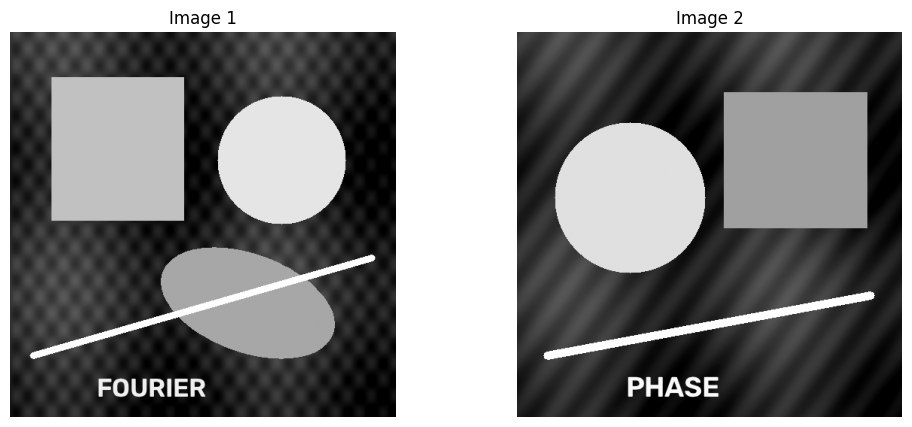

Fourier transform calculated.


In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from IPython.display import display

# Upload your images in Google Colab if you want to use your own
USE_SYNTHETIC_FALLBACK = True

IMAGE_PATH_1 = "/content/image1.jpg"
IMAGE_PATH_2 = "/content/image2.jpg"

def synthetic_image(kind=1, size=(512, 512)):
    h, w = size
    y, x = np.mgrid[0:h, 0:w]

    img_float = 35 + 20*np.sin(x/45) + 15*np.cos(y/55)

    if kind == 1:
        img_float += 18*np.sin(x/5) * np.cos(y/7)
    else:
        img_float += 12*np.sin(x/8 + y/11)

    img = np.clip(img_float, 0, 255).astype(np.uint8)

    if kind == 1:
        cv2.rectangle(img, (55, 60), (230, 250), 185, -1)
        cv2.circle(img, (360, 170), 85, 220, -1)
        cv2.ellipse(img, (315, 360), (120, 65),
                    20, 0, 360, 160, -1)
        cv2.line(img, (30, 430), (480, 300), 245, 8)
        cv2.putText(img, "FOURIER", (115, 485),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2, 230, 3, cv2.LINE_AA)
    else:
        cv2.circle(img, (150, 220), 100, 210, -1)
        cv2.rectangle(img, (275, 80), (465, 260), 150, -1)
        cv2.line(img, (40, 430), (470, 350), 240, 10)
        cv2.putText(img, "PHASE", (145, 485),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, 235, 3, cv2.LINE_AA)

    return img


def load_gray(path, fallback_kind=1):
    if path and os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img

    if USE_SYNTHETIC_FALLBACK:
        return synthetic_image(fallback_kind)

    raise FileNotFoundError(f"Could not load image: {path}")


img1 = load_gray(IMAGE_PATH_1, 1)
img2 = load_gray(IMAGE_PATH_2, 2)

H, W = img1.shape
img2 = cv2.resize(img2, (W, H))

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Image 1")
ax[0].axis("off")

ax[1].imshow(img2, cmap="gray")
ax[1].set_title("Image 2")
ax[1].axis("off")

plt.show()


# Common Fourier Transform utilities

def fft2_shift(img):
    F = np.fft.fft2(img)
    return np.fft.fftshift(F)


def ifft2_shift(F_shifted):
    return np.real(
        np.fft.ifft2(np.fft.ifftshift(F_shifted))
    )


def magnitude_spectrum(F):
    return np.log1p(np.abs(F))


def phase_spectrum(F):
    return np.angle(F)


def normalize_uint8(img):
    img = np.asarray(img, dtype=np.float32)
    mn, mx = img.min(), img.max()

    if mx - mn < 1e-12:
        return np.zeros_like(img, dtype=np.uint8)

    return np.clip(
        (img - mn) * 255.0 / (mx - mn),
        0, 255
    ).astype(np.uint8)


def distance_grid(shape):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2

    return np.sqrt((x - cx)**2 + (y - cy)**2)


F1 = fft2_shift(img1)
print("Fourier transform calculated.")


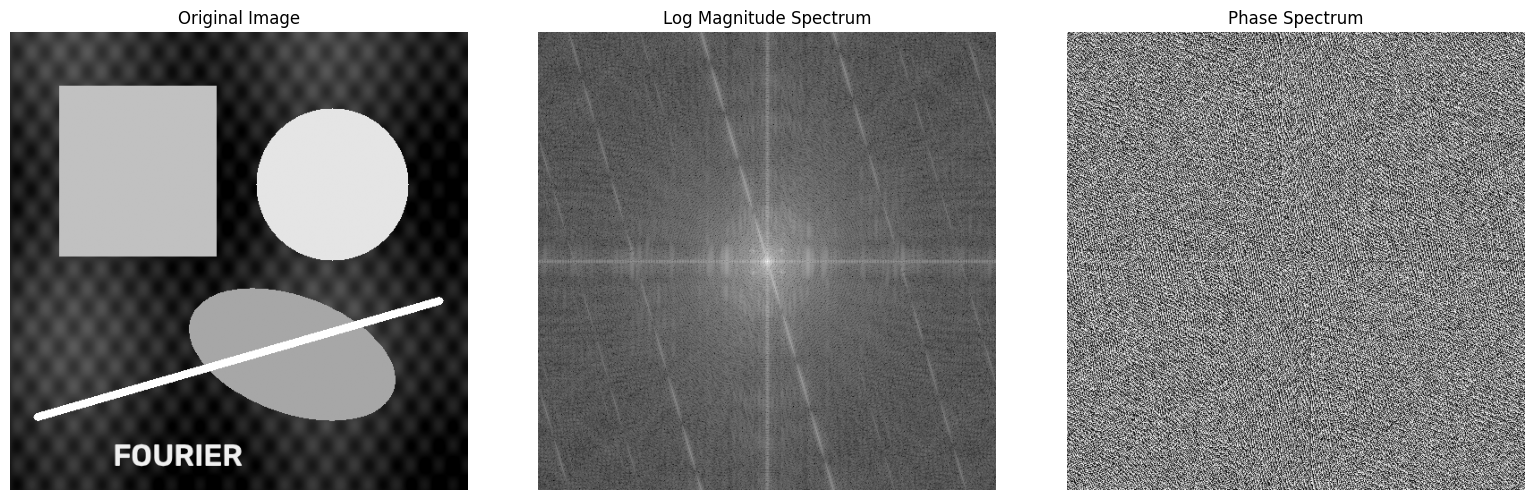

Magnitude range: 13.750359011007417 to 22715805.0
Phase range: -3.142 to 3.142 radians


In [2]:

# TASK 1: 2D FOURIER MAGNITUDE + PHASE

F = fft2_shift(img1)

mag = magnitude_spectrum(F)
phase = phase_spectrum(F)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mag, cmap="gray")
ax[1].set_title("Log Magnitude Spectrum")
ax[1].axis("off")

ax[2].imshow(phase, cmap="gray")
ax[2].set_title("Phase Spectrum")
ax[2].axis("off")

plt.tight_layout()
plt.show()

print("Magnitude range:",
      float(np.abs(F).min()),
      "to", float(np.abs(F).max()))

print("Phase range: {:.3f} to {:.3f} radians".format(
    phase.min(), phase.max()
))


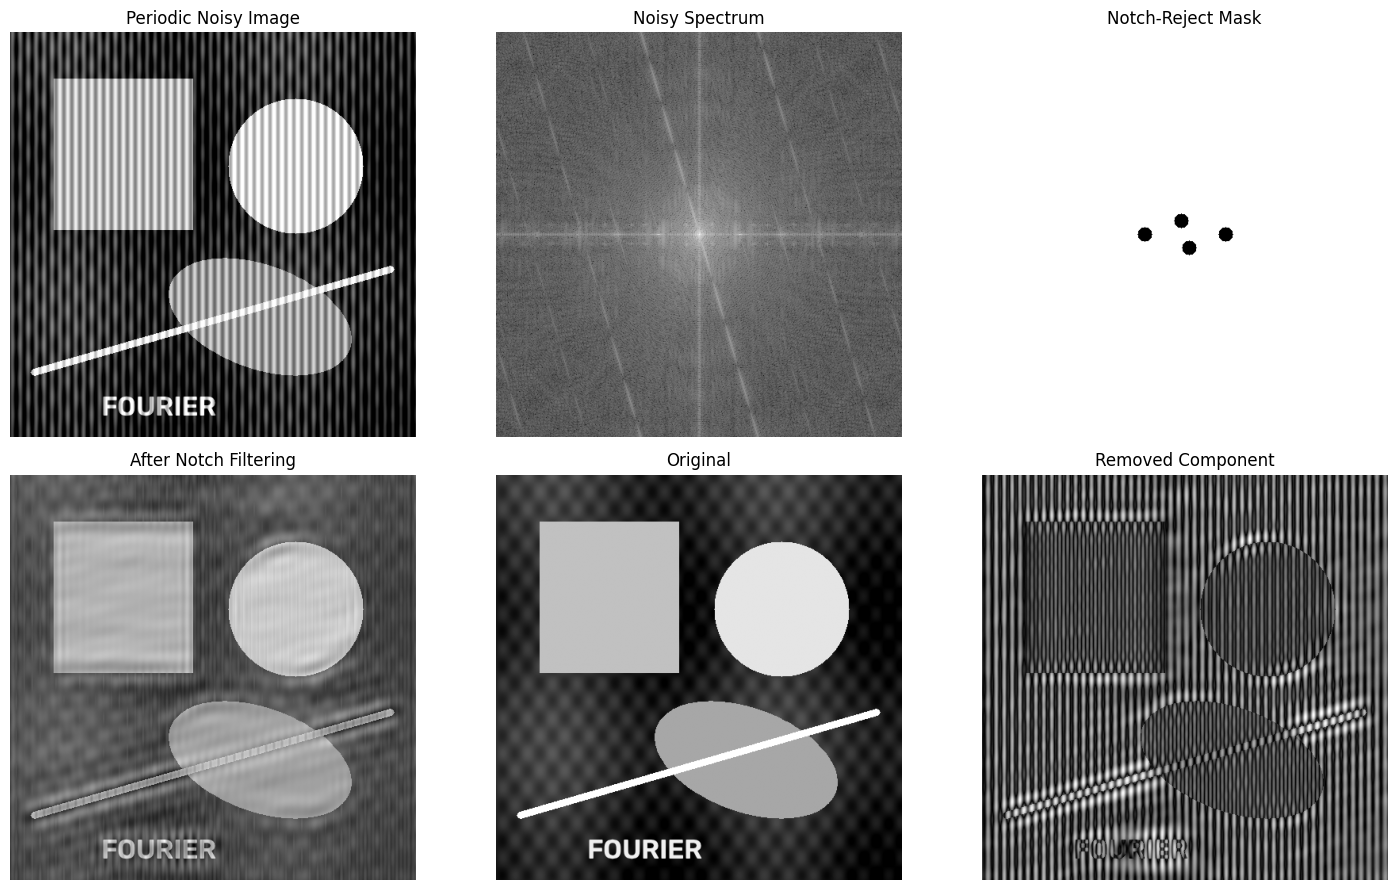

Detected spectral peak coordinates: [(np.int64(256), np.int64(205)), (np.int64(256), np.int64(307)), (np.int64(239), np.int64(251)), (np.int64(273), np.int64(261))]


In [4]:

# TASK 4: PERIODIC NOISE + AUTOMATIC NOTCH REJECTION

def add_periodic_noise(img, amplitude=45, fx=0.08, fy=0.0):
    h, w = img.shape
    y, x = np.mgrid[0:h, 0:w]

    noise = amplitude * np.sin(
        2 * np.pi * (fx * x + fy * y)
    )

    noisy = np.clip(
        img.astype(np.float32) + noise, 0, 255
    )

    return noisy.astype(np.uint8)


def find_spectral_peaks(F, count=4, exclusion_radius=12):
    mag = np.abs(F).copy()
    h, w = mag.shape
    cy, cx = h // 2, w // 2

    yy, xx = np.ogrid[:h, :w]

    center_mask = (
        (xx - cx)**2 + (yy - cy)**2
        <= exclusion_radius**2
    )

    mag[center_mask] = 0
    coords = []

    for _ in range(count):
        idx = np.argmax(mag)
        py, px = np.unravel_index(idx, mag.shape)
        coords.append((py, px))

        y1 = max(0, py - exclusion_radius)
        y2 = min(h, py + exclusion_radius + 1)
        x1 = max(0, px - exclusion_radius)
        x2 = min(w, px + exclusion_radius + 1)

        mag[y1:y2, x1:x2] = 0

    return coords


def notch_reject(shape, centers, radius=7):
    h, w = shape
    yy, xx = np.ogrid[:h, :w]

    Hn = np.ones((h, w), dtype=np.float32)

    for cy, cx in centers:
        mask = (
            (yy - cy)**2 + (xx - cx)**2
            <= radius**2
        )
        Hn[mask] = 0

    return Hn


noisy = add_periodic_noise(
    img1, amplitude=55, fx=0.10
)

Fn = fft2_shift(noisy)

peaks = find_spectral_peaks(
    Fn, count=4, exclusion_radius=14
)

H_notch = notch_reject(
    noisy.shape, peaks, radius=9
)

cleaned = normalize_uint8(
    ifft2_shift(Fn * H_notch)
)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))

ax[0, 0].imshow(noisy, cmap="gray")
ax[0, 0].set_title("Periodic Noisy Image")

ax[0, 1].imshow(np.log1p(np.abs(Fn)), cmap="gray")
ax[0, 1].set_title("Noisy Spectrum")

ax[0, 2].imshow(H_notch, cmap="gray")
ax[0, 2].set_title("Notch-Reject Mask")

ax[1, 0].imshow(cleaned, cmap="gray")
ax[1, 0].set_title("After Notch Filtering")

ax[1, 1].imshow(img1, cmap="gray")
ax[1, 1].set_title("Original")

ax[1, 2].imshow(
    np.abs(noisy.astype(float) - cleaned.astype(float)),
    cmap="gray"
)
ax[1, 2].set_title("Removed Component")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

print("Detected spectral peak coordinates:", peaks)


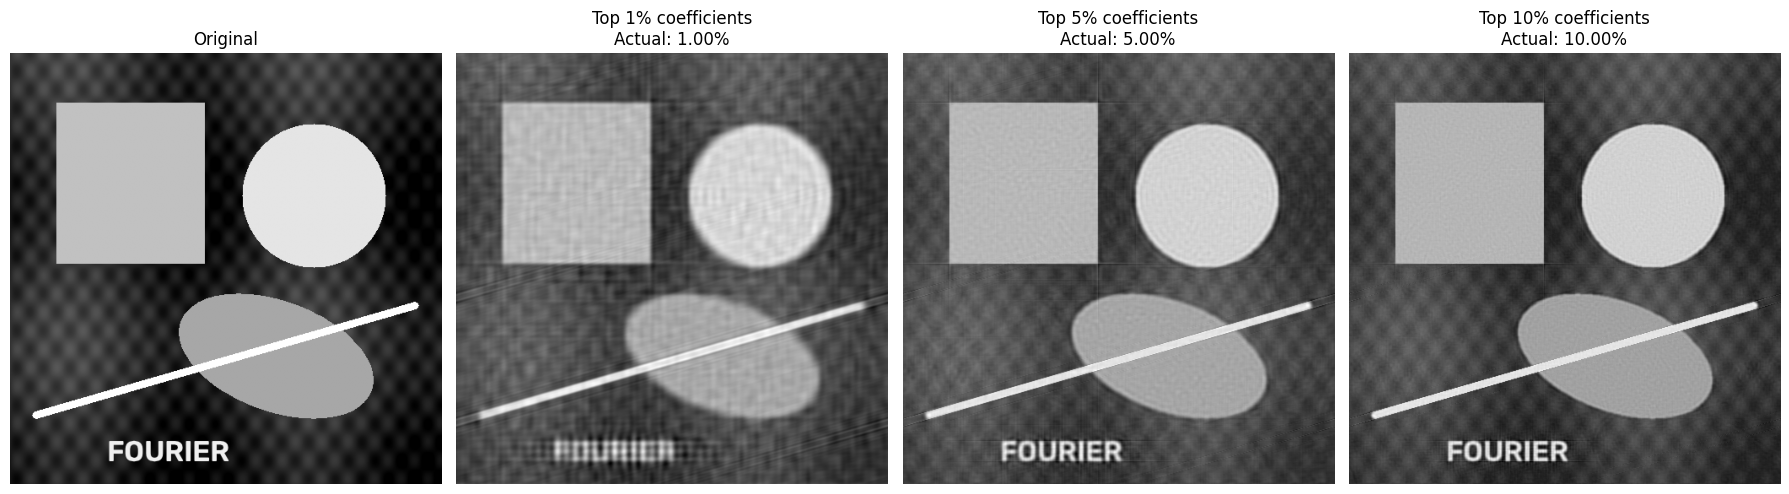

In [5]:

# TASK 5: TOP-K FOURIER COEFFICIENT COMPRESSION

def top_k_fourier_reconstruction(img, keep_percent=5):
    F = fft2_shift(img)

    flat = np.abs(F).ravel()
    k = max(1, int(len(flat) * keep_percent / 100.0))

    threshold = np.partition(flat, -k)[-k]
    mask = np.abs(F) >= threshold

    F_keep = F * mask

    reconstructed = normalize_uint8(
        ifft2_shift(F_keep)
    )

    actual_percent = (
        100 * np.count_nonzero(mask) / mask.size
    )

    return reconstructed, mask, actual_percent


percentages = [1, 5, 10]

fig, ax = plt.subplots(
    1, len(percentages) + 1, figsize=(18, 5)
)

ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

for i, p in enumerate(percentages, start=1):
    rec, mask, actual = top_k_fourier_reconstruction(
        img1, p
    )

    ax[i].imshow(rec, cmap="gray")
    ax[i].set_title(
        f"Top {p}% coefficients\nActual: {actual:.2f}%"
    )
    ax[i].axis("off")

plt.tight_layout()
plt.show()


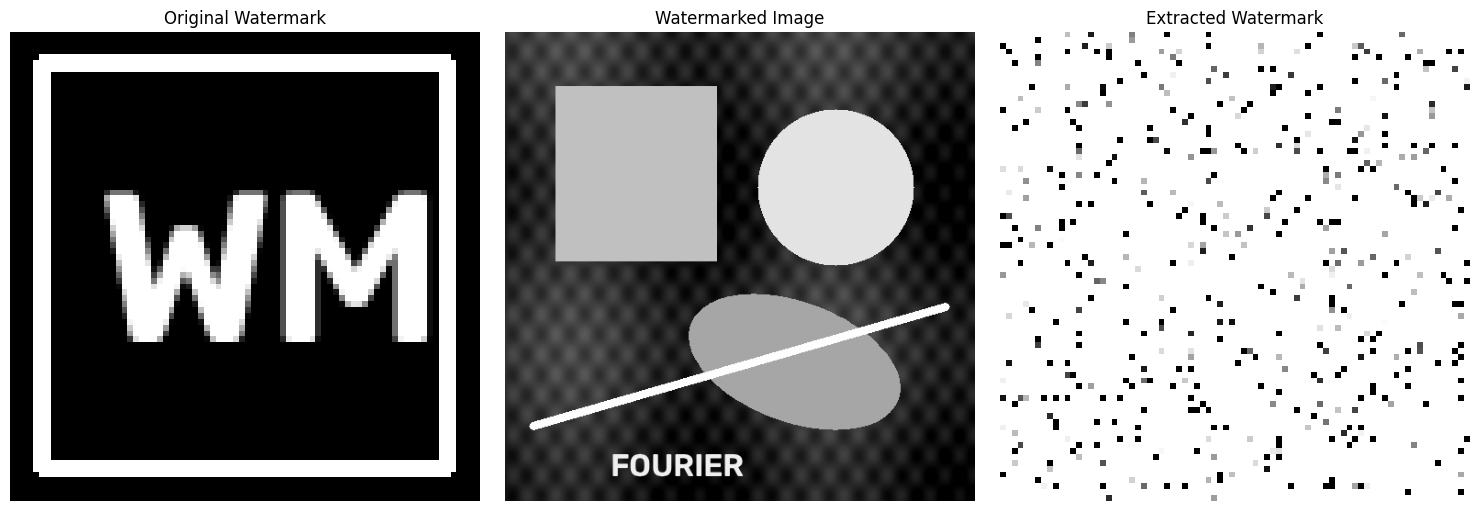

In [6]:

# TASK 6: FREQUENCY-DOMAIN WATERMARK EMBEDDING + EXTRACTION

def make_watermark(size=(80, 80)):
    wm = np.zeros(size, dtype=np.uint8)

    cv2.rectangle(
        wm, (5, 5), (size[1] - 6, size[0] - 6),
        255, 2
    )

    cv2.putText(
        wm, "WM", (15, 53),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.25, 255, 2, cv2.LINE_AA
    )

    return wm


def embed_watermark(img, watermark, strength=18, seed=123):
    F = fft2_shift(img).astype(np.complex128)

    h, w = img.shape
    wh, ww = watermark.shape

    rng = np.random.default_rng(seed)
    candidates = []
    cy, cx = h // 2, w // 2

    # Select coefficients in a high-frequency annulus
    for y in range(h):
        for x in range(w):
            r = np.sqrt((y - cy)**2 + (x - cx)**2)

            if min(h, w)*0.22 < r < min(h, w)*0.38:
                candidates.append((y, x))

    rng.shuffle(candidates)

    n = wh * ww
    selected = candidates[:n]

    wm_flat = watermark.ravel() / 255.0

    for (y, x), bit in zip(selected, wm_flat):
        current = np.abs(F[y, x])

        F[y, x] = (
            current + strength * bit
        ) * np.exp(1j * np.angle(F[y, x]))

    # Approximately preserve conjugate symmetry
    for y, x in selected:
        yy = (2 * cy - y) % h
        xx = (2 * cx - x) % w
        F[yy, xx] = np.conj(F[y, x])

    watermarked = normalize_uint8(ifft2_shift(F))

    return watermarked, F, selected


def extract_watermark(
    original_img, watermarked_img,
    watermark_shape, strength=18, seed=123
):
    F0 = fft2_shift(original_img).astype(np.complex128)
    Fw = fft2_shift(watermarked_img).astype(np.complex128)

    h, w = original_img.shape
    wh, ww = watermark_shape

    rng = np.random.default_rng(seed)
    candidates = []
    cy, cx = h // 2, w // 2

    for y in range(h):
        for x in range(w):
            r = np.sqrt((y - cy)**2 + (x - cx)**2)

            if min(h, w)*0.22 < r < min(h, w)*0.38:
                candidates.append((y, x))

    rng.shuffle(candidates)
    selected = candidates[:wh * ww]

    values = []

    for y, x in selected:
        delta = (
            np.abs(Fw[y, x]) - np.abs(F0[y, x])
        ) / max(strength, 1e-8)

        values.append(delta)

    wm = np.clip(
        np.array(values).reshape(wh, ww), 0, 1
    ) * 255

    return wm.astype(np.uint8)


watermark = make_watermark()

watermarked, Fw, selected = embed_watermark(
    img1, watermark, strength=20
)

extracted = extract_watermark(
    img1, watermarked, watermark.shape, strength=20
)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(watermark, cmap="gray")
ax[0].set_title("Original Watermark")

ax[1].imshow(watermarked, cmap="gray")
ax[1].set_title("Watermarked Image")

ax[2].imshow(extracted, cmap="gray")
ax[2].set_title("Extracted Watermark")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


Frequency filtering functions defined successfully!


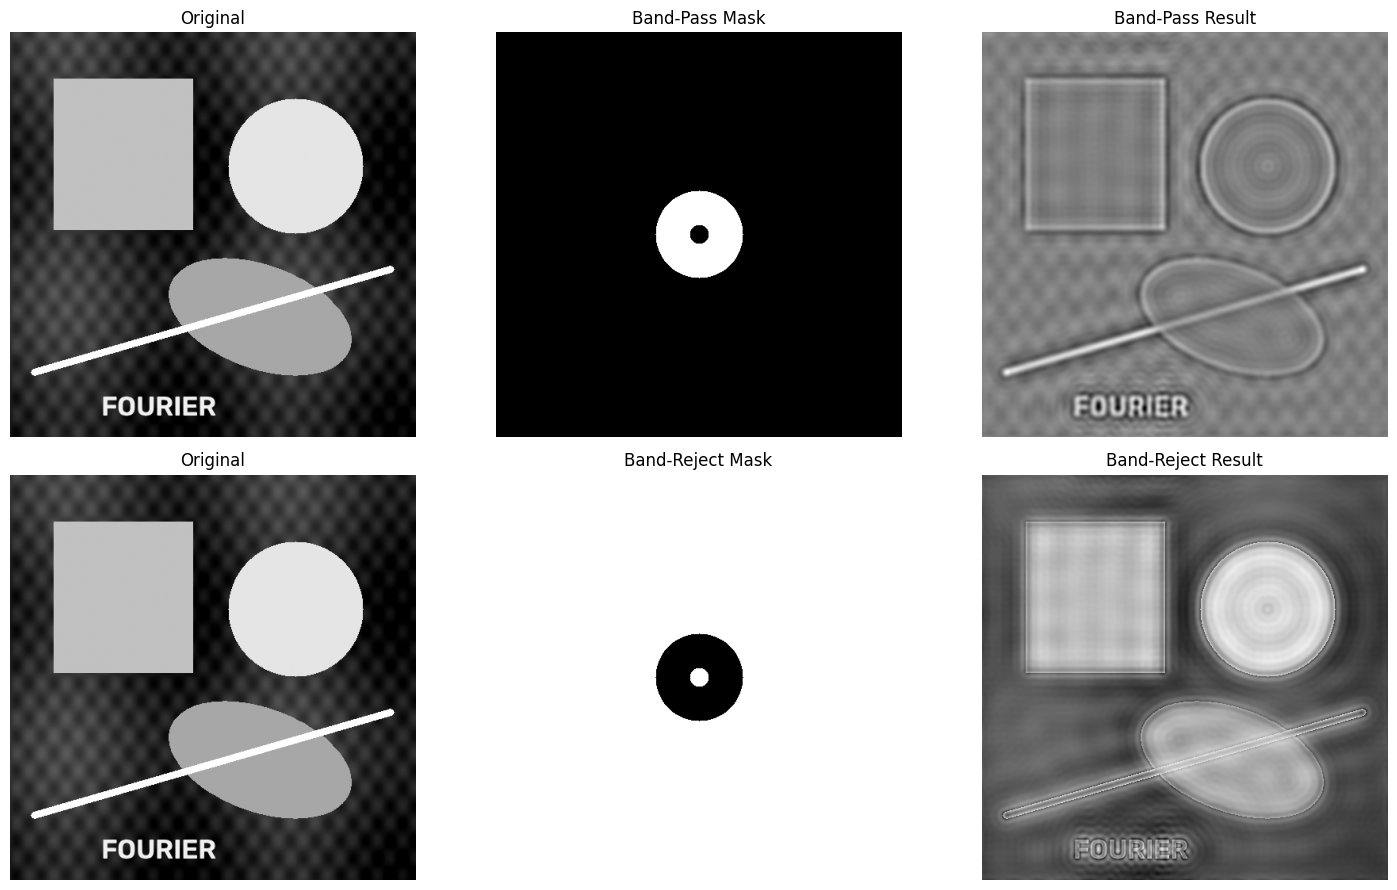

In [9]:

# TASK 7: BAND-PASS + BAND-REJECT FILTER DESIGNER

def fft2_shift(img):
    F = np.fft.fft2(img)
    return np.fft.fftshift(F)


def ifft2_shift(F_shifted):
    return np.real(
        np.fft.ifft2(np.fft.ifftshift(F_shifted))
    )


def normalize_uint8(img):
    img = np.asarray(img, dtype=np.float32)
    mn, mx = img.min(), img.max()

    if mx - mn < 1e-12:
        return np.zeros_like(img, dtype=np.uint8)

    return np.clip(
        (img - mn) * 255.0 / (mx - mn),
        0, 255
    ).astype(np.uint8)


def apply_frequency_filter(img, H_filter):
    F = fft2_shift(img)
    G = F * H_filter
    result = ifft2_shift(G)
    return normalize_uint8(result)


def distance_grid(shape):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2

    return np.sqrt((x - cx)**2 + (y - cy)**2)


print("Frequency filtering functions defined successfully!")

def ideal_bandpass(shape, D_low, D_high):
    D = distance_grid(shape)

    return (
        (D >= D_low) & (D <= D_high)
    ).astype(np.float32)


def ideal_bandreject(shape, D_low, D_high):
    return 1.0 - ideal_bandpass(
        shape, D_low, D_high
    )


D_low, D_high = 12, 55

H_bp = ideal_bandpass(
    img1.shape, D_low, D_high
)

H_br = ideal_bandreject(
    img1.shape, D_low, D_high
)

bandpass = apply_frequency_filter(img1, H_bp)
bandreject = apply_frequency_filter(img1, H_br)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))

ax[0, 0].imshow(img1, cmap="gray")s
ax[0, 0].set_title("Original")

ax[0, 1].imshow(H_bp, cmap="gray")
ax[0, 1].set_title("Band-Pass Mask")

ax[0, 2].imshow(bandpass, cmap="gray")
ax[0, 2].set_title("Band-Pass Result")

ax[1, 0].imshow(img1, cmap="gray")
ax[1, 0].set_title("Original")

ax[1, 1].imshow(H_br, cmap="gray")
ax[1, 1].set_title("Band-Reject Mask")

ax[1, 2].imshow(bandreject, cmap="gray")
ax[1, 2].set_title("Band-Reject Result")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()


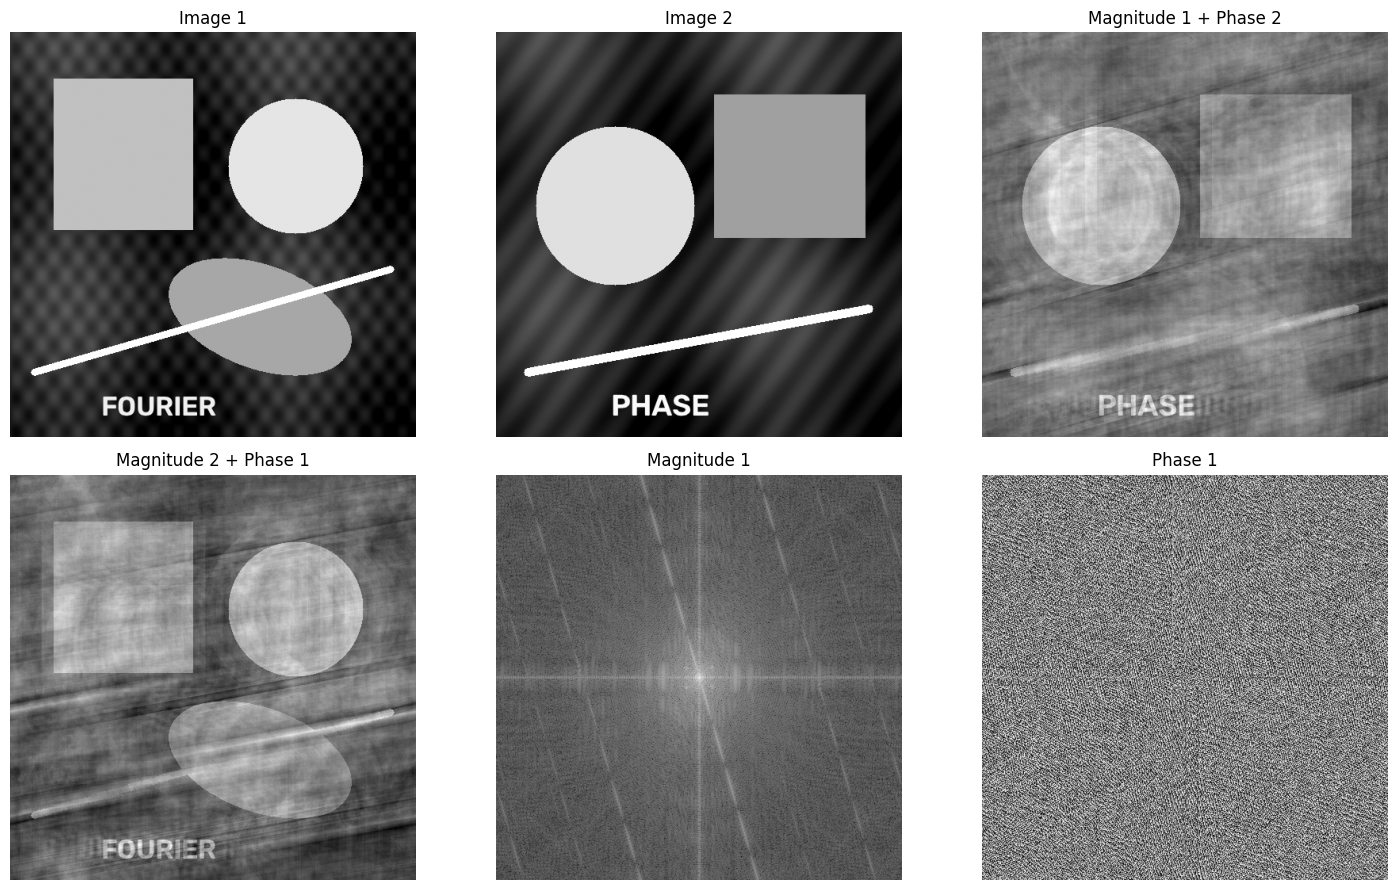

In [10]:

# TASK 8: PHASE / MAGNITUDE SWAP

F_a = fft2_shift(img1)
F_b = fft2_shift(img2)

mag_a, phase_a = np.abs(F_a), np.angle(F_a)
mag_b, phase_b = np.abs(F_b), np.angle(F_b)

# Magnitude of Image 1 + Phase of Image 2
swap_mag_a_phase_b = np.real(
    np.fft.ifft2(
        np.fft.ifftshift(
            mag_a * np.exp(1j * phase_b)
        )
    )
)

# Magnitude of Image 2 + Phase of Image 1
swap_mag_b_phase_a = np.real(
    np.fft.ifft2(
        np.fft.ifftshift(
            mag_b * np.exp(1j * phase_a)
        )
    )
)

swap_mag_a_phase_b = normalize_uint8(
    swap_mag_a_phase_b
)

swap_mag_b_phase_a = normalize_uint8(
    swap_mag_b_phase_a
)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))

ax[0, 0].imshow(img1, cmap="gray")
ax[0, 0].set_title("Image 1")

ax[0, 1].imshow(img2, cmap="gray")
ax[0, 1].set_title("Image 2")

ax[0, 2].imshow(swap_mag_a_phase_b, cmap="gray")
ax[0, 2].set_title("Magnitude 1 + Phase 2")

ax[1, 0].imshow(swap_mag_b_phase_a, cmap="gray")
ax[1, 0].set_title("Magnitude 2 + Phase 1")

ax[1, 1].imshow(np.log1p(mag_a), cmap="gray")
ax[1, 1].set_title("Magnitude 1")

ax[1, 2].imshow(phase_a, cmap="gray")
ax[1, 2].set_title("Phase 1")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()


,Image,High-frequency energy,Decision
0,Sharp,0.011366,BLURRY
1,Blurred,0.000097,BLURRY


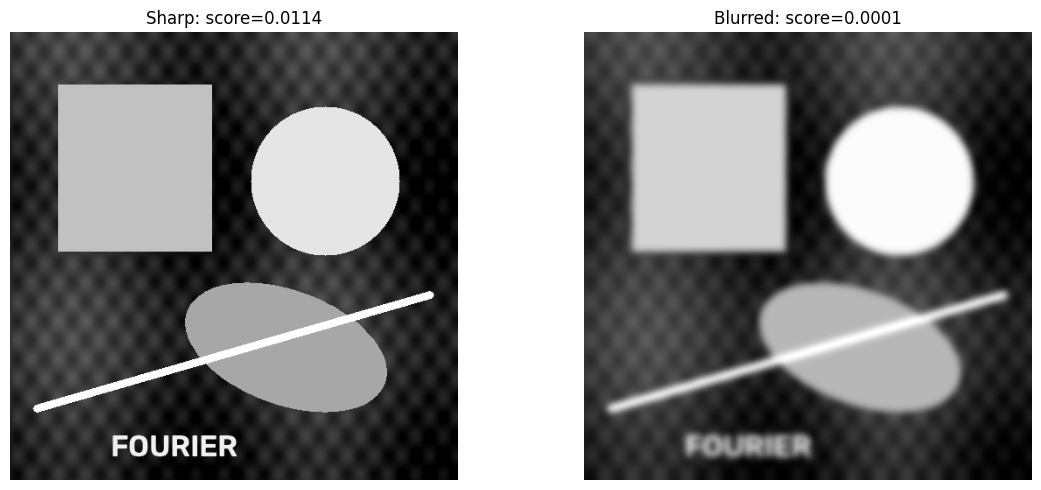

Blur threshold used: 0.08
Calibrate the threshold for real images.


In [11]:

# TASK 9: BLUR DETECTION

def high_frequency_energy_score(img, cutoff_ratio=0.12):
    F = fft2_shift(img)
    power = np.abs(F)**2
    D = distance_grid(img.shape)

    cutoff = cutoff_ratio * min(img.shape)

    high = power[D > cutoff].sum()
    total = power.sum()

    return float(high / max(total, 1e-12))


def blur_detector(img, threshold=0.08):
    score = high_frequency_energy_score(img)

    label = "SHARP" if score >= threshold else "BLURRY"

    return score, label


# Create sharp and blurred examples
sharp = img1.copy()

blur_sigma = 4
blurred = cv2.GaussianBlur(
    sharp, (0, 0), blur_sigma
)

score_sharp, label_sharp = blur_detector(sharp)
score_blur, label_blur = blur_detector(blurred)

results = pd.DataFrame({
    "Image": ["Sharp", "Blurred"],
    "High-frequency energy": [
        score_sharp, score_blur
    ],
    "Decision": [
        label_sharp, label_blur
    ]
})

display(results)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(sharp, cmap="gray")
ax[0].set_title(
    f"Sharp: score={score_sharp:.4f}"
)

ax[1].imshow(blurred, cmap="gray")
ax[1].set_title(
    f"Blurred: score={score_blur:.4f}"
)

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

print("Blur threshold used:", 0.08)
print("Calibrate the threshold for real images.")


gaussian_lowpass() defined successfully!


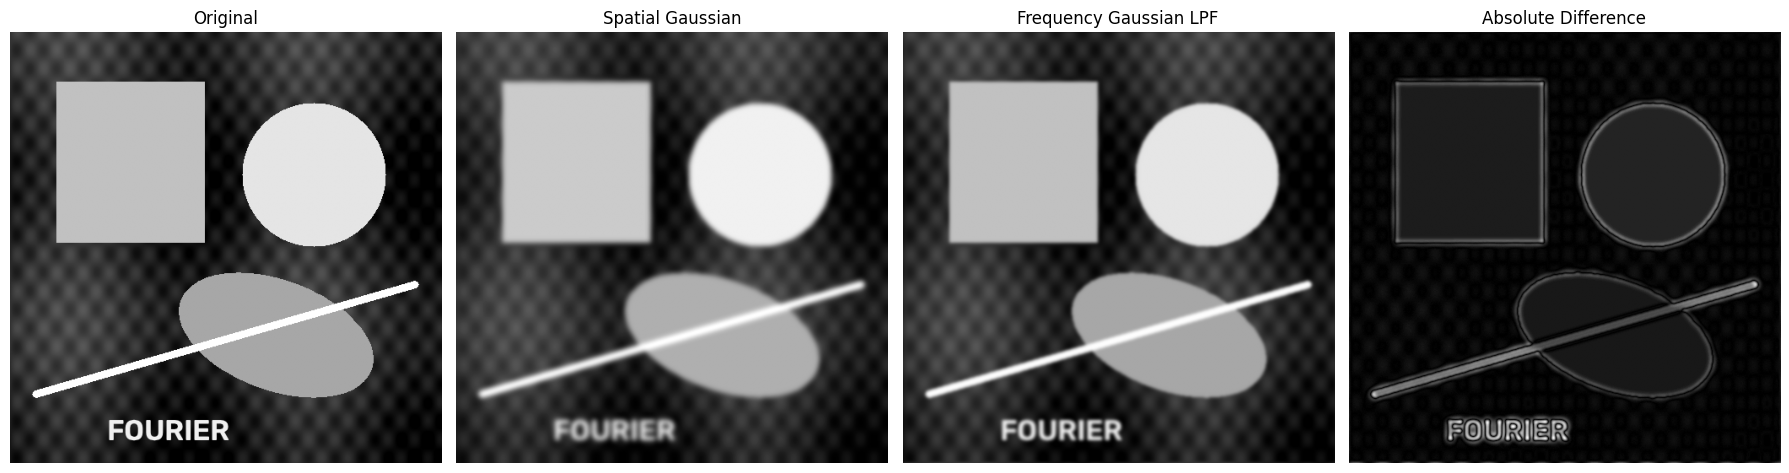

Mean absolute difference: 5.527957916259766


In [15]:

import numpy as np

def distance_grid(shape):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    return np.sqrt((x - cx)**2 + (y - cy)**2)


def gaussian_lowpass(shape, D0):
    D = distance_grid(shape)
    return np.exp(-(D**2) / (2 * D0**2))


print("gaussian_lowpass() defined successfully!")

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a sample image only if img1 does not exist
if "img1" not in globals():
    img1 = np.zeros((512, 512), dtype=np.uint8)
    cv2.rectangle(img1, (80, 80), (430, 430), 200, -1)
    cv2.circle(img1, (256, 256), 100, 100, -1)


def distance_grid(shape):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    return np.sqrt((x - cx)**2 + (y - cy)**2)


def gaussian_lowpass(shape, D0):
    D = distance_grid(shape)
    return np.exp(-(D**2) / (2 * D0**2))


def apply_frequency_filter(img, H_filter):
    F = np.fft.fftshift(np.fft.fft2(img))
    G = F * H_filter

    result = np.real(
        np.fft.ifft2(np.fft.ifftshift(G))
    )

    mn, mx = result.min(), result.max()

    if mx - mn < 1e-12:
        return np.zeros_like(img, dtype=np.uint8)

    return np.clip(
        (result - mn) * 255.0 / (mx - mn),
        0, 255
    ).astype(np.uint8)


# TASK 10: SPATIAL VS FREQUENCY-DOMAIN FILTERING

spatial_blur = cv2.GaussianBlur(
    img1, (0, 0), sigmaX=3
)

freq_gaussian_mask = gaussian_lowpass(
    img1.shape, D0=45
)

frequency_blur = apply_frequency_filter(
    img1, freq_gaussian_mask
)

difference = cv2.absdiff(
    spatial_blur, frequency_blur
)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))

ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(spatial_blur, cmap="gray")
ax[1].set_title("Spatial Gaussian")

ax[2].imshow(frequency_blur, cmap="gray")
ax[2].set_title("Frequency Gaussian LPF")

ax[3].imshow(difference, cmap="gray")
ax[3].set_title("Absolute Difference")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

mean_difference = np.mean(
    np.abs(
        spatial_blur.astype(float)
        - frequency_blur.astype(float)
    )
)

print("Mean absolute difference:", float(mean_difference))

